In [51]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Path to src_Jeffery.py
src_path = Path("../Pysimulations").resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import src_Jeffery as jf

# Step 1. Classical Jeffery orbit

The first case considers an elongated passive particle suspended in a simple shear flow. No swimming or optical effects are included. For a simple shear flow in the xy-plane 
$$ \mathbf{u} = (\dot{\gamma}y,0,0) $$

the velocity-gradient tensor ir 

$$
\mathbf{G} = \nabla\mathbf{u}=
\begin{pmatrix}
0 & \dot{\gamma} & 0\\
0 & 0 & 0\\
0 & 0 & 0
\end{pmatrix}.
$$
Then is decomosed into its symmetric and antisymmetric parts

$$
\mathbf{E} = \frac{1}{2}
\left(\mathbf{G}+\mathbf{G}^T\right)=
\begin{pmatrix}
0 & \dot{\gamma} & 0\\
\dot{\gamma} & 0 & 0\\
0 & 0 & 0
\end{pmatrix},
$$

$$
\mathbf{W} = \frac{1}{2}
\left(\mathbf{G}-\mathbf{G}^T\right)=
\begin{pmatrix}
0 & \dot{\gamma} & 0\\
-\dot{\gamma} & 0 & 0\\
0 & 0 & 0
\end{pmatrix}.
$$ 

The director follows the Jeffery´s equation:

$$ \dot{\mathbf{p}}= \mathbf{Wp}+\beta[\mathbf{Ep}-(\mathbf{p}^T\mathbf{Ep})\mathbf{p}] $$

In [52]:
import tomli
from pathlib import Path

parameter_file = Path("parameters.toml")

with open(parameter_file, "rb") as f:
    params = tomli.load(f)

# PARTICLE PARAMETERS

Length = params["particle"]["length"]
diameter = params["particle"]["diameter"]

swimming_speed = params["particle"]["swimming_speed"]

eta = params["particle"]["eta"]

n_particle = params["particle"]["n_particle"]
n_medium = params["particle"]["n_medium"]


# INITIAL CONDITIONS

R0 = np.array([
    params["initial"]["x0"],
    params["initial"]["y0"],
    params["initial"]["z0"]
], dtype=float)

theta0_deg = params["initial"]["theta0_deg"]
phi0_deg = params["initial"]["phi0_deg"]


# FLOW PARAMETERS

gamma = params["flow"]["gamma"]
plane = params["flow"]["plane"]


# OPTICAL PARAMETERS

wavelength = params["optics"]["wavelength"]
w0 = params["optics"]["w0"]
laser_power = params["optics"]["laser_power"]

beam_axis = np.array(
    params["optics"]["beam_axis"],
    dtype=float
)

e_pol = np.array(
    params["optics"]["polarization"],
    dtype=float
)


# SIMULATION PARAMETERS

t0 = params["simulation"]["t0"]
tf = params["simulation"]["tf"]
n_points = params["simulation"]["n_points"]
rtol = params["simulation"]["rtol"]
atol = params["simulation"]["atol"]



print("PARTICLE")
print("Length =", Length, "m")
print("diameter =", diameter, "m")
print("swimming_speed =", swimming_speed, "m/s")
print("eta =", eta, "Pa s")
print("n_particle =", n_particle)
print("n_medium =", n_medium)

print()

print("INITIAL CONDITIONS")
print("R0 =", R0, "m")
print("theta0 =", theta0_deg, "deg")
print("phi0 =", phi0_deg, "deg")

print()

print("FLOW")
print("gamma =", gamma, "1/s")
print("plane =", plane)

print()

print("OPTICS")
print("wavelength =", wavelength, "m")
print("w0 =", w0, "m")
print("laser_power =", laser_power, "W")
print("beam_axis =", beam_axis)
print("polarization =", e_pol)



print()

print("SIMULATION")
print("t0 =", t0, "s")
print("tf =", tf, "s")
print("n_points =", n_points)


PARTICLE
Length = 5e-07 m
diameter = 7e-08 m
swimming_speed = 1e-05 m/s
eta = 0.000953 Pa s
n_particle = 1.38
n_medium = 1.33

INITIAL CONDITIONS
R0 = [0. 0. 0.] m
theta0 = 25.0 deg
phi0 = 25.0 deg

FLOW
gamma = 1 1/s
plane = xz

OPTICS
wavelength = 1.064e-06 m
w0 = 1.9e-06 m
laser_power = 0.025 W
beam_axis = [0. 0. 1.]
polarization = [0. 1. 0.]

SIMULATION
t0 = 0.0 s
tf = 300.0 s
n_points = 4000


In [53]:
#Particle Geometry
aspect_ratio = Length/diameter

beta = jf.lambda_ar(aspect_ratio)
print("Bretherton parameter: ",beta)
print("With aspecto ratio of: ",aspect_ratio)

a = Length/2
b = diameter/2

Volume = (4/3)*np.pi*a*(b**2)
print("the volume is:", Volume, "m^3")

alpha_scalar = jf.alpha(Volume, n_particle, n_medium)
print("The particle's polarizability is:", alpha_scalar)

Bretherton parameter:  0.9615535504119262
With aspecto ratio of:  7.142857142857142
the volume is: 1.2828170002158323e-21 m^3
The particle's polarizability is: 8.483977117647845e-34


In [54]:
#angle to radians 
theta0 = np.deg2rad(theta0_deg)
phi0 = np.deg2rad(phi0_deg)

p0 = jf.sph_to_vec(theta0, phi0)
print("the initial orientation is p: ", p0)
print("||p0|| =", np.linalg.norm(p0))

the initial orientation is p:  [0.38302222 0.1786062  0.90630779]
||p0|| = 1.0


In [55]:
#Background flow

G = jf.grad_u_simple_shear(gamma,plane)

E, W = jf.decompose_grad_u(G)

print("Velocity gradient G:")
print(G)

print("\nRate-of-strain tensor E:")
print(E)

print("\nRotation tensor W:")
print(W)

Velocity gradient G:
[[0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]]

Rate-of-strain tensor E:
[[0.  0.  0.5]
 [0.  0.  0. ]
 [0.5 0.  0. ]]

Rotation tensor W:
[[ 0.   0.   0.5]
 [ 0.   0.   0. ]
 [-0.5  0.   0. ]]


The orientation vector traces a closed orbit on the unit sphere; these closed orbits are formed by infinitely many marginally stable periodic orbits and are called $\textbf{degenerated}$. The period of one rotation does not depend on $\theta$ but is determined by the shear strength and the Bretherton parameter:
$$ T= \frac{2\pi}{\gamma}\left(c+\frac{1}{c}\right)=\frac{4\pi}{\gamma\sqrt{1-\beta^2}}$$

In [56]:
T_Jeffery = (2.0*np.pi/gamma)*(aspect_ratio+(1/aspect_ratio))
print("Expected Jeffery period =", T_Jeffery, "s")

Expected Jeffery period = 45.759540994287896 s


## Jeffery equation

$$ \dot{\mathbf{p}}= \mathbf{Wp}+\beta[\mathbf{Ep}-(\mathbf{p}^T\mathbf{Ep})\mathbf{p}] $$

In [57]:
p_dot_0 = jf.jeffery_rhs_vector(t0,p0,E,W,beta)
print("p0 =", p0)
print("p_dot(0) =", p_dot_0)
print("||p_dot(0)|| =", np.linalg.norm(p_dot_0))

p0 = [0.38302222 0.1786062  0.90630779]
p_dot(0) = [ 0.76103669 -0.05961694 -0.30987928]
||p_dot(0)|| = 0.823866611340437


In [58]:
t_eval = np.linspace(t0,tf,n_points)

sol_jeffery = solve_ivp(
    fun=lambda t, p: jf.jeffery_rhs_vector(t,p,E,W,beta),
    t_span=(t0, tf),
    y0=p0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_jeffery.success:
    raise RuntimeError(
        sol_jeffery.message
    )

In [59]:
P_raw = sol_jeffery.y.T

norm_raw = np.linalg.norm(P_raw,axis=1)

P = jf.normalize_rows(P_raw)
p0_sim = P[0]
pf = P[-1]

px = P[:, 0]
py = P[:, 1]
pz = P[:, 2]

print("Initial director =", p0_sim)
print("Final director =", pf)

print(
    "Maximum norm error =",
    np.max(np.abs(norm_raw - 1.0))
)

Initial director = [0.38302222 0.1786062  0.90630779]
Final director = [-0.9500432   0.06548931 -0.30517054]
Maximum norm error = 4.6707227863151957e-08


In [60]:
theta, phitan, phi = jf.directors_to_angles(P)

theta_deg = np.rad2deg(theta)
phi_deg = np.rad2deg(phi)

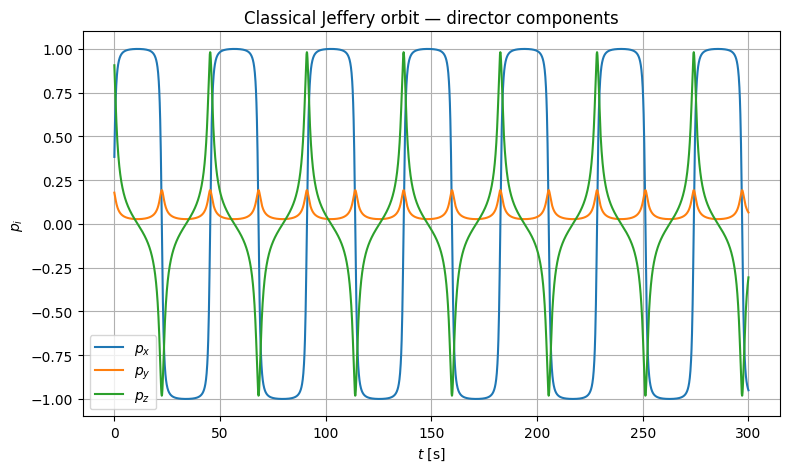

In [61]:
plt.figure(figsize=(9, 5))

plt.plot(
    sol_jeffery.t,
    px,
    label=r"$p_x$"
)

plt.plot(
    sol_jeffery.t,
    py,
    label=r"$p_y$"
)

plt.plot(
    sol_jeffery.t,
    pz,
    label=r"$p_z$"
)

plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$p_i$")

plt.title(
    "Classical Jeffery orbit — director components"
)

plt.grid(True)
plt.legend()

plt.show()

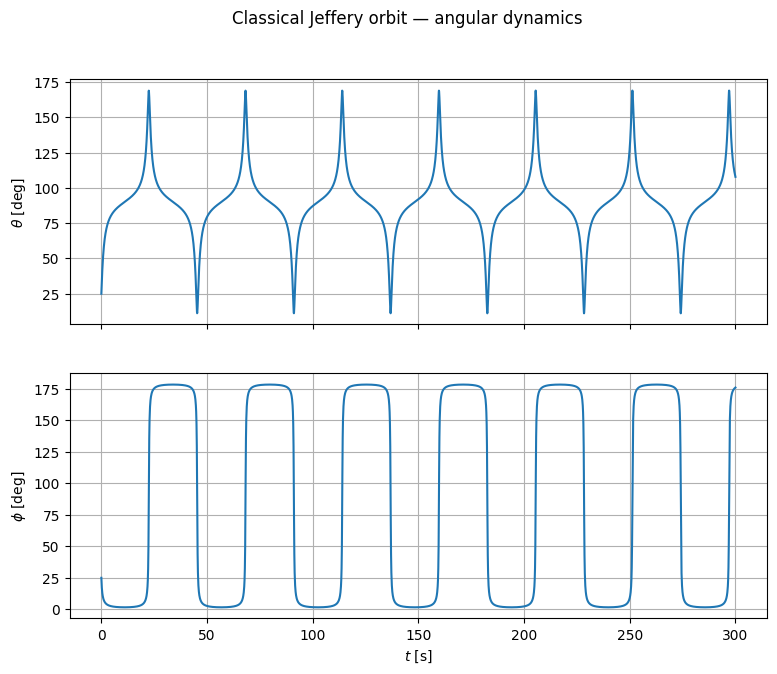

In [62]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)

ax[0].plot(
    sol_jeffery.t,
    theta_deg
)

ax[0].set_ylabel(
    r"$\theta$ [deg]"
)

ax[0].grid(True)

ax[1].plot(
    sol_jeffery.t,
    phi_deg
)

ax[1].set_xlabel(
    r"$t$ [s]"
)

ax[1].set_ylabel(
    r"$\phi$ [deg]"
)

ax[1].grid(True)

plt.suptitle(
    "Classical Jeffery orbit — angular dynamics"
)

plt.show()

In [63]:
import pyvista as pv
pv.set_jupyter_backend("server")
# ============================================================
# 3D REFERENCE GEOMETRY

plotter = pv.Plotter(
    window_size=(1100, 800)
)

plotter.set_background("white")

# Unit sphere S^2

sphere = pv.Sphere(
    radius=1.0,
    theta_resolution=80,
    phi_resolution=80
)

plotter.add_mesh(
    sphere,
    color="lightgray",
    opacity=0.22,
    smooth_shading=True,
    specular=0.15,
    show_edges=False
)


# ------------------------------------------------------------
# Initial particle orientation p0
# ------------------------------------------------------------

p0_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p0,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    p0_arrow,
    color="green"
)

p0_point = pv.PolyData(
    p0.reshape(1, 3)
)

plotter.add_mesh(
    p0_point,
    color="green",
    point_size=9,
    render_points_as_spheres=True
)


# Jeffery trajectory on S^2
trajectory = pv.Spline(
    P,
    P.shape[0]
)

plotter.add_mesh(
    trajectory,
    color="red",
    line_width=4
)

pf_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=pf,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    pf_arrow,
    color="blue"
)

pf_point = pv.PolyData(
    pf.reshape(1, 3)
)

plotter.add_mesh(
    pf_point,
    color="blue",
    point_size=9,
    render_points_as_spheres=True
)

# ------------------------------------------------------------
# Background velocity field
# ------------------------------------------------------------

grid = np.linspace(-1.0, 1.0, 11)

points = []
vectors = []

for a_grid in grid:
    for b_grid in grid:

        if plane == "xy":
            X = np.array([
                a_grid,
                b_grid,
                0.0
            ])

        elif plane == "xz":
            X = np.array([
                a_grid,
                0.0,
                b_grid
            ])

        elif plane == "yz":
            X = np.array([
                0.0,
                a_grid,
                b_grid
            ])

        else:
            raise ValueError(
                "plane must be 'xy', 'xz' or 'yz'"
            )

        u = G @ X

        points.append(X)
        vectors.append(u)


points = np.asarray(points)
vectors = np.asarray(vectors)

flow_mesh = pv.PolyData(points)

flow_mesh["velocity"] = vectors

flow_glyphs = flow_mesh.glyph(
    orient="velocity",
    scale="velocity",
    factor=0.30
)

plotter.add_mesh(
    flow_glyphs,
    color="black",
    opacity=0.80
)


# ------------------------------------------------------------
# Axes and bounds
# ------------------------------------------------------------

plotter.add_axes(
    line_width=3,
    xlabel="x",
    ylabel="y",
    zlabel="z"
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    color="black",
    xtitle="px",
    ytitle="py",
    ztitle="pz",
    font_size=18
)


# ------------------------------------------------------------
# Text
# ------------------------------------------------------------

if plane == "xy":

    flow_text = (
        f"u = ({gamma:g} y, 0, 0)"
    )

elif plane == "xz":

    flow_text = (
        f"u = ({gamma:g} z, 0, 0)"
    )

elif plane == "yz":

    flow_text = "simple shear in yz"


plotter.add_text(
    "Reference geometry on S^2\n"
    f"{flow_text}\n"
    f"c = {aspect_ratio:.3f}, beta = {beta:.3f}",
    position="upper_left",
    font_size=16,
    color="black"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plotter.add_legend(
    labels=[
        ["initial orientation p0", "green"],
        ["final orientation pf", "blue"],
        ["Jeffery orbit", "red"],
        ["background flow", "black"]
    ],
    bcolor="white",
    border=False,
    face="circle",
    size=(0.22, 0.18)
)


# ------------------------------------------------------------
# Camera
# ------------------------------------------------------------

plotter.camera_position = "iso"
plotter.camera.zoom(1.15)

plotter.show()

Widget(value='<iframe src="http://localhost:57725/index.html?ui=P_0x146f06a60_4&reconnect=auto" class="pyvista…

# Step 2. Orbits with intensity gradient torques

Here we model the classic Jeffery orbits, but now with the presence of an intensity gradient torque caused by a laser beam, which is assumed to be harmonic. Hence, the direction vector will be modeled as
$$\mathbf{\dot{p}} = \dot{p}_{Jeffery}+\dot{p}_{grad} $$

The intensity gradient torque is added while the particle center of mass is assumed to be fixed at the trap center.

The objective is to determine how the optical alignment toward the beam axis modifies the classical Jeffery orbit.  

In [64]:
#Harmonic trap parameters
zR = jf.rayleigh_range(w0,wavelength) 

U0 = jf.trap_depth(alpha_scalar,laser_power,w0)

kx, ky, kz = jf.harmonic_stiffness_from_gaussian(U0,w0,zR)

print("Rayleigh range zR =", zR, "m")
print("Trap depth U0 =", U0, "J")

print()
print("Harmonic stiffnesses:")
print("kx =", kx, "N/m")
print("ky =", ky, "N/m")
print("kz =", kz, "N/m")

Rayleigh range zR = 1.0658975074679655e-05 m
Trap depth U0 = 1.4091037978393884e-21 J

Harmonic stiffnesses:
kx = 1.5613338480214828e-09 N/m
ky = 1.5613338480214828e-09 N/m
kz = 2.480516314744559e-11 N/m


In [65]:
k_perp = 0.5 * (kx + ky)

kappa_grad = (
    (a**2 - b**2)
    / 10.0
    * (k_perp - kz)
)

print("kappa_grad =",kappa_grad,"J")

kappa_grad = 9.415079516565662e-24 J


In [66]:
effective_radius = diameter / 2.0

rotational_drag = jf.rotational_drag_sphere(eta=eta,effective_radius=effective_radius)

xi_grad = jf.alignment_rate_from_torque(kappa_grad,rotational_drag)

In [67]:
def jeffery_gradient_rhs(t, p):

    # Jeffery contribution
    p_dot_jeffery = jf.jeffery_rhs_vector(
        t=t,
        p=p,
        E=E,
        W=W,
        lam=beta
    )

    # Intensity-gradient torque contribution
    p_dot_gradient = jf.uniaxial_alignment_drift(
        p=p,
        axis=beam_axis,
        alignment_rate=xi_grad
    )

    return (
        p_dot_jeffery
        + p_dot_gradient
    )

In [68]:
p_dot_jeffery_0 = jf.jeffery_rhs_vector(
    t=0.0,
    p=p0,
    E=E,
    W=W,
    lam=beta
)

p_dot_gradient_0 = jf.uniaxial_alignment_drift(p0,beam_axis,xi_grad)

print(
    "||p_dot_Jeffery|| =",
    np.linalg.norm(p_dot_jeffery_0),
    "1/s"
)

print(
    "||p_dot_gradient|| =",
    np.linalg.norm(p_dot_gradient_0),
    "1/s"
)

||p_dot_Jeffery|| = 0.823866611340437 1/s
||p_dot_gradient|| = 7.023297505751036 1/s


In [69]:
t_eval = np.linspace(
    t0,
    tf,
    n_points
)

sol_gradient = solve_ivp(
    fun=jeffery_gradient_rhs,
    t_span=(t0, tf),
    y0=p0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_gradient.success:
    raise RuntimeError(
        sol_gradient.message
    )

In [70]:
P_raw = sol_gradient.y.T

norm_raw = np.linalg.norm(
    P_raw,
    axis=1
)

P = jf.normalize_rows(P_raw)

# Components
px = P[:, 0]
py = P[:, 1]
pz = P[:, 2]

# Initial and final director
p_initial = P[0]
pf = P[-1]

norm_error = np.abs(norm_raw - 1.0)

print("p0 =", p_initial)
print("pf =", pf)
print("maximum norm error =", np.max(norm_error))

p0 = [0.38302222 0.1786062  0.90630779]
pf = [5.34142346e-02 1.04905390e-12 9.98572441e-01]
maximum norm error = 1.6973977778889093e-11


In [71]:
theta_rad, phi_rad_wrapped, phi_rad_unwrapped = (
    jf.directors_to_angles(P)
)

theta_deg = np.rad2deg(
    theta_rad
)

phi_deg = np.rad2deg(
    phi_rad_unwrapped
)

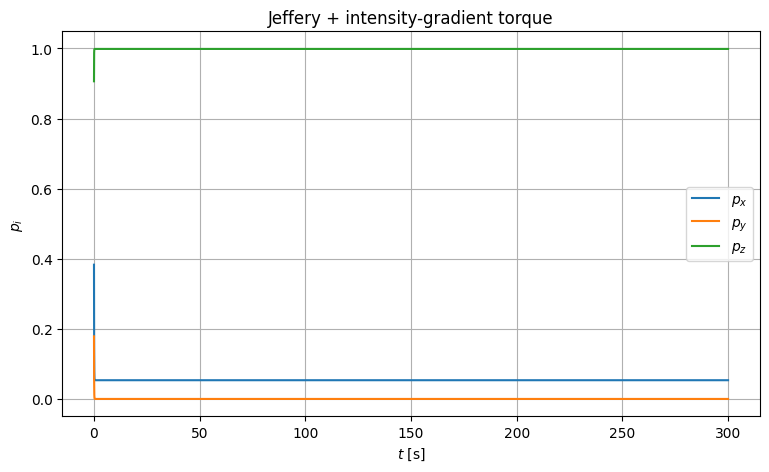

In [72]:
# ============================================================
# P COMPONENTS VS TIME
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(sol_gradient.t, px, label=r"$p_x$")
plt.plot(sol_gradient.t, py, label=r"$p_y$")
plt.plot(sol_gradient.t, pz, label=r"$p_z$")

plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$p_i$")
plt.title("Jeffery + intensity-gradient torque")
plt.grid(True)
plt.legend()

plt.show()

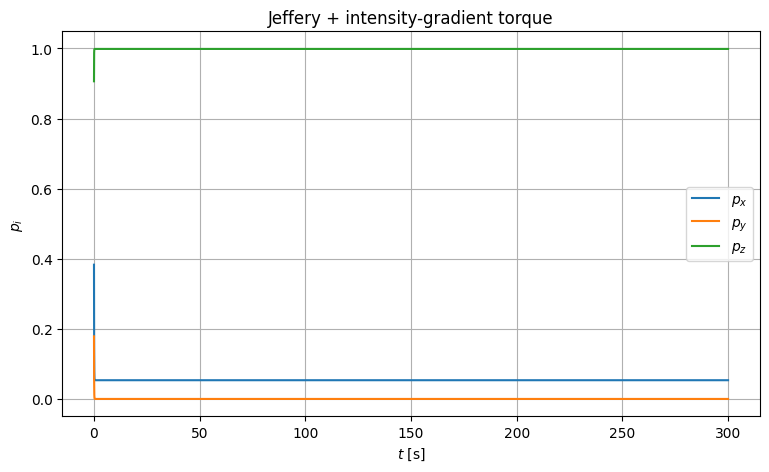

In [73]:
# ============================================================
# P COMPONENTS VS TIME
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(sol_gradient.t, px, label=r"$p_x$")
plt.plot(sol_gradient.t, py, label=r"$p_y$")
plt.plot(sol_gradient.t, pz, label=r"$p_z$")

plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$p_i$")
plt.title("Jeffery + intensity-gradient torque")
plt.grid(True)
plt.legend()

plt.show()

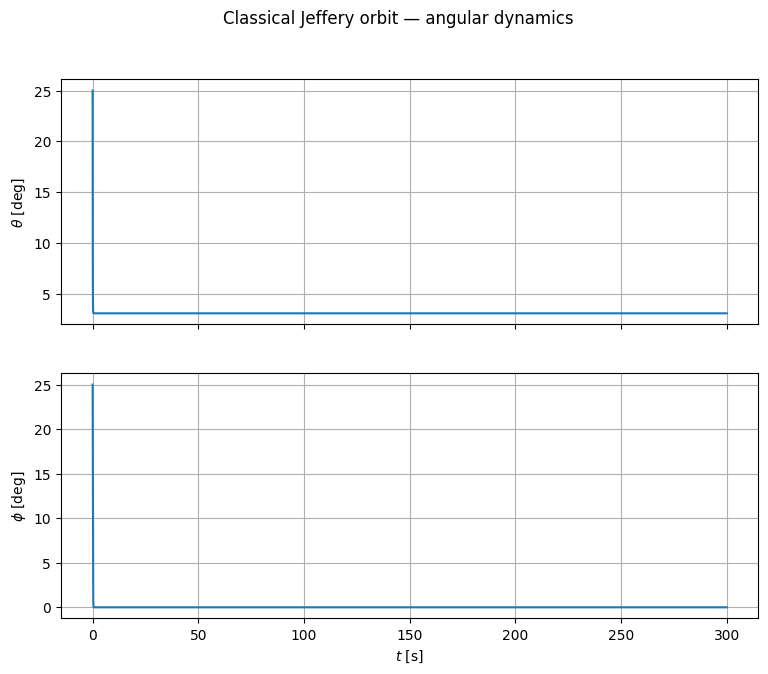

In [74]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True
)

ax[0].plot(
    sol_jeffery.t,
    theta_deg
)

ax[0].set_ylabel(
    r"$\theta$ [deg]"
)

ax[0].grid(True)

ax[1].plot(
    sol_jeffery.t,
    phi_deg
)

ax[1].set_xlabel(
    r"$t$ [s]"
)

ax[1].set_ylabel(
    r"$\phi$ [deg]"
)

ax[1].grid(True)

plt.suptitle(
    "Classical Jeffery orbit — angular dynamics"
)

plt.show()

In [75]:
import pyvista as pv
pv.set_jupyter_backend("server")
# ============================================================
# 3D REFERENCE GEOMETRY

# ============================================================
# 3D ORBIT ON S^2
# ============================================================

plotter = pv.Plotter(window_size=(1100, 800))
plotter.set_background("white")

# ------------------------------------------------------------
# Unit sphere
# ------------------------------------------------------------

sphere = pv.Sphere(
    radius=1.0,
    theta_resolution=80,
    phi_resolution=80
)

plotter.add_mesh(
    sphere,
    color="lightgray",
    opacity=0.22,
    smooth_shading=True,
    specular=0.15,
    show_edges=False
)

# ------------------------------------------------------------
# Initial orientation p0
# ------------------------------------------------------------

p0_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p_initial,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    p0_arrow,
    color="green"
)

p0_point = pv.PolyData(
    p_initial.reshape(1, 3)
)

plotter.add_mesh(
    p0_point,
    color="green",
    point_size=10,
    render_points_as_spheres=True
)

# ------------------------------------------------------------
# Final orientation pf
# ------------------------------------------------------------

pf_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=pf,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    pf_arrow,
    color="blue"
)

pf_point = pv.PolyData(
    pf.reshape(1, 3)
)

plotter.add_mesh(
    pf_point,
    color="blue",
    point_size=10,
    render_points_as_spheres=True
)

# ------------------------------------------------------------
# Trajectory p(t) on S^2
# ------------------------------------------------------------

trajectory = pv.Spline(
    P,
    P.shape[0]
)

plotter.add_mesh(
    trajectory,
    color="red",
    line_width=4
)

# ------------------------------------------------------------
# Background flow field
# ------------------------------------------------------------

grid = np.linspace(-1.0, 1.0, 11)

points = []
vectors = []

for a_grid in grid:
    for b_grid in grid:

        if plane == "xy":
            X = np.array([a_grid, b_grid, 0.0])

        elif plane == "xz":
            X = np.array([a_grid, 0.0, b_grid])

        elif plane == "yz":
            X = np.array([0.0, a_grid, b_grid])

        else:
            raise ValueError("plane must be 'xy', 'xz' or 'yz'")

        u = G @ X

        points.append(X)
        vectors.append(u)

points = np.asarray(points)
vectors = np.asarray(vectors)

# optional normalization only for visualization
max_velocity = np.max(np.linalg.norm(vectors, axis=1))
if max_velocity > 0:
    vectors_plot = vectors / max_velocity
else:
    vectors_plot = vectors.copy()

flow_mesh = pv.PolyData(points)
flow_mesh["velocity_plot"] = vectors_plot

flow_glyphs = flow_mesh.glyph(
    orient="velocity_plot",
    scale="velocity_plot",
    factor=0.30
)

plotter.add_mesh(
    flow_glyphs,
    color="black",
    opacity=0.80
)

# ------------------------------------------------------------
# Beam axis (because now there is optical alignment toward z)
# ------------------------------------------------------------

beam_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=beam_axis,
    tip_length=0.18,
    tip_radius=0.04,
    shaft_radius=0.012,
    scale=0.85
)

plotter.add_mesh(
    beam_arrow,
    color="orange"
)

# ------------------------------------------------------------
# Axes and bounds
# ------------------------------------------------------------

plotter.add_axes(
    line_width=3,
    xlabel="x",
    ylabel="y",
    zlabel="z"
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    color="black",
    xtitle="px",
    ytitle="py",
    ztitle="pz",
    font_size=18
)

# ------------------------------------------------------------
# Flow text
# ------------------------------------------------------------

if plane == "xy":
    flow_text = f"u = ({gamma:g} y, 0, 0)"
elif plane == "xz":
    flow_text = f"u = ({gamma:g} z, 0, 0)"
elif plane == "yz":
    flow_text = "simple shear in yz"

plotter.add_text(
    "Jeffery orbit with intensity-gradient torque\n"
    f"{flow_text}\n"
    f"c = {aspect_ratio:.3f}, beta = {beta:.3f}, "
    f"xi_grad = {xi_grad:.3e} 1/s",
    position="upper_left",
    font_size=15,
    color="black"
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

plotter.add_legend(
    labels=[
        ["p(t)", "red"],
        ["initial orientation p0", "green"],
        ["final orientation pf", "blue"],
        ["beam axis", "orange"],
        ["background flow", "black"]
    ],
    bcolor="white",
    border=False,
    face="circle",
    size=(0.25, 0.22)
)

# ------------------------------------------------------------
# Camera
# ------------------------------------------------------------

plotter.camera_position = "iso"
plotter.camera.zoom(1.15)

plotter.show()

Widget(value='<iframe src="http://localhost:57725/index.html?ui=P_0x1470e74c0_5&reconnect=auto" class="pyvista…